In [923]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score


from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV


In [924]:
df = pd.read_csv("train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      38000 non-null  int64  
 1   num_1   38000 non-null  int64  
 2   num_2   38000 non-null  int64  
 3   num_3   38000 non-null  int64  
 4   num_4   38000 non-null  int64  
 5   num_5   38000 non-null  int64  
 6   num_6   38000 non-null  int64  
 7   num_7   38000 non-null  float64
 8   num_8   38000 non-null  int64  
 9   num_9   38000 non-null  float64
 10  cat_1   38000 non-null  str    
 11  cat_2   38000 non-null  str    
 12  cat_3   38000 non-null  str    
 13  cat_4   38000 non-null  str    
 14  cat_5   38000 non-null  str    
 15  cat_6   38000 non-null  str    
 16  cat_7   38000 non-null  str    
 17  target  38000 non-null  int64  
dtypes: float64(2), int64(9), str(7)
memory usage: 5.2 MB


In [925]:
# check missing values
print(df.isnull().sum())

# check duplicate
print(df.duplicated().sum())

id        0
num_1     0
num_2     0
num_3     0
num_4     0
num_5     0
num_6     0
num_7     0
num_8     0
num_9     0
cat_1     0
cat_2     0
cat_3     0
cat_4     0
cat_5     0
cat_6     0
cat_7     0
target    0
dtype: int64
0


In [926]:
#  encoding categorical features


cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))


In [927]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      38000 non-null  int64  
 1   num_1   38000 non-null  int64  
 2   num_2   38000 non-null  int64  
 3   num_3   38000 non-null  int64  
 4   num_4   38000 non-null  int64  
 5   num_5   38000 non-null  int64  
 6   num_6   38000 non-null  int64  
 7   num_7   38000 non-null  float64
 8   num_8   38000 non-null  int64  
 9   num_9   38000 non-null  float64
 10  cat_1   38000 non-null  int64  
 11  cat_2   38000 non-null  int64  
 12  cat_3   38000 non-null  int64  
 13  cat_4   38000 non-null  int64  
 14  cat_5   38000 non-null  int64  
 15  cat_6   38000 non-null  int64  
 16  cat_7   38000 non-null  int64  
 17  target  38000 non-null  int64  
dtypes: float64(2), int64(16)
memory usage: 5.2 MB


In [928]:

# FE
eps = 1e-5

df["loan_income_ratio"] = df["num_3"] / (df["num_2"] + eps)
df["monthly_payment"] = df["num_3"] / (df["num_8"] + eps)

drop_cols = [
    "num_2",
    "num_8"
]

df = df.drop(columns=drop_cols)
print("Remaining features:", df.shape[1])

X = df.drop(columns=['target'])

for feature in X : 
    df[feature] = np.log1p(X[feature])
    
y = df['target']



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# check target distribution 
df['target'].value_counts()



Remaining features: 18


target
0    23000
1    15000
Name: count, dtype: int64

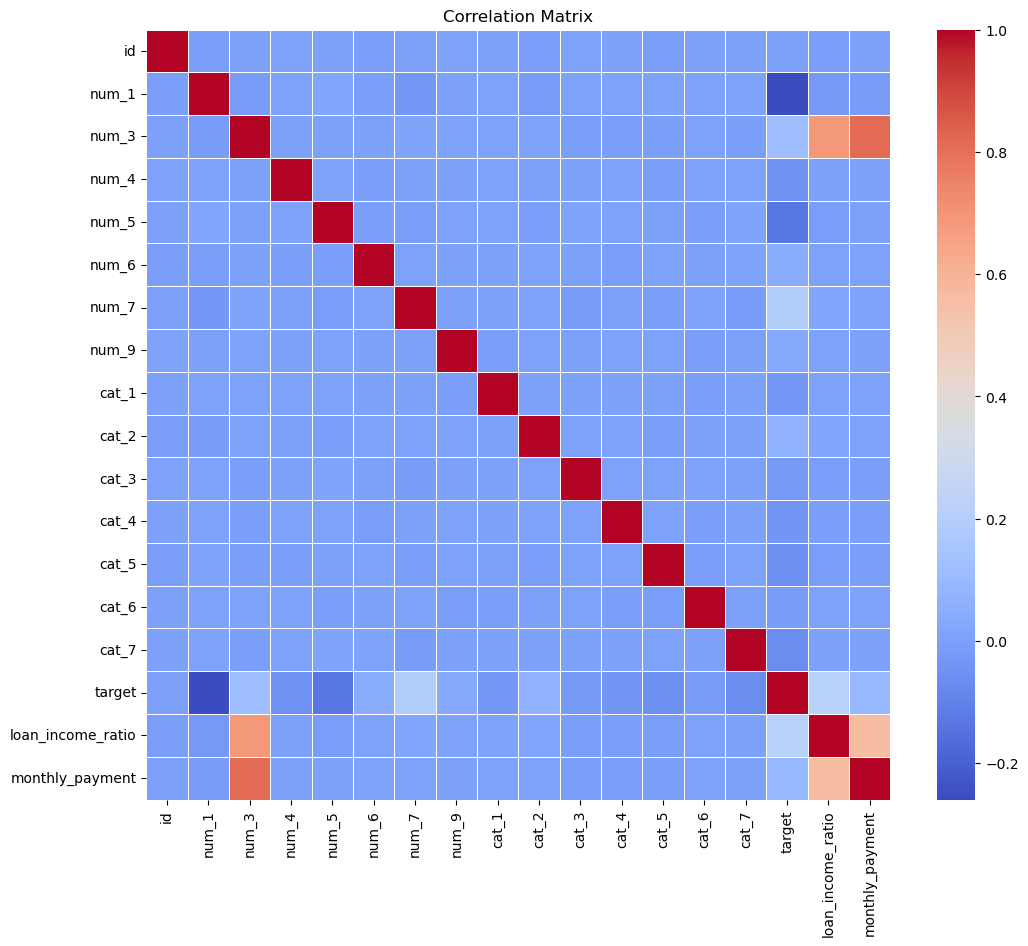

In [929]:
corr_matrix =df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [930]:
def roc_curve(model, X, y):
    from sklearn.metrics import roc_curve, auc
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

def cmap(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='cubehelix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

              precision    recall  f1-score   support

           0       0.73      0.82      0.77      4617
           1       0.65      0.53      0.59      2983

    accuracy                           0.70      7600
   macro avg       0.69      0.67      0.68      7600
weighted avg       0.70      0.70      0.70      7600



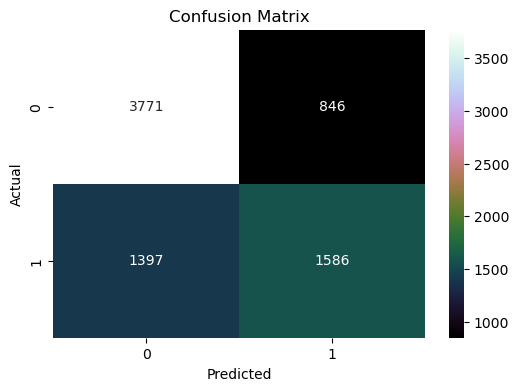

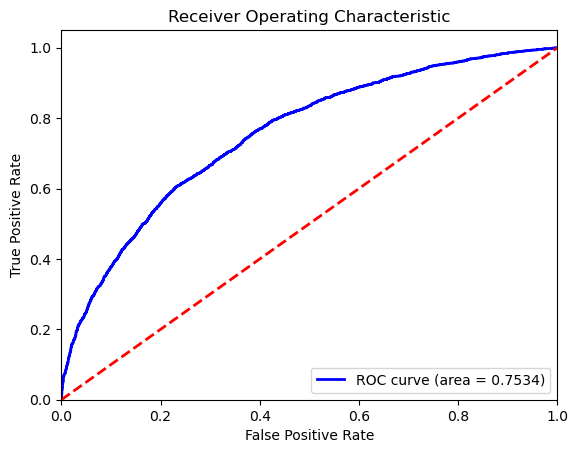

In [931]:
# Train baseline model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

# Predict
y_pred = baseline_model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))
cmap(baseline_model, X_test, y_test)
roc_curve(baseline_model, X_test, y_test)




              precision    recall  f1-score   support

           0       0.73      0.82      0.77      4617
           1       0.65      0.53      0.59      2983

    accuracy                           0.70      7600
   macro avg       0.69      0.67      0.68      7600
weighted avg       0.70      0.70      0.70      7600



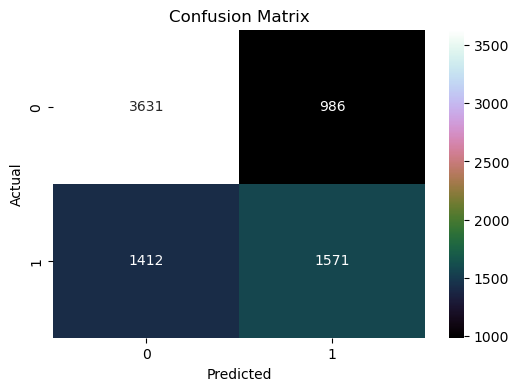

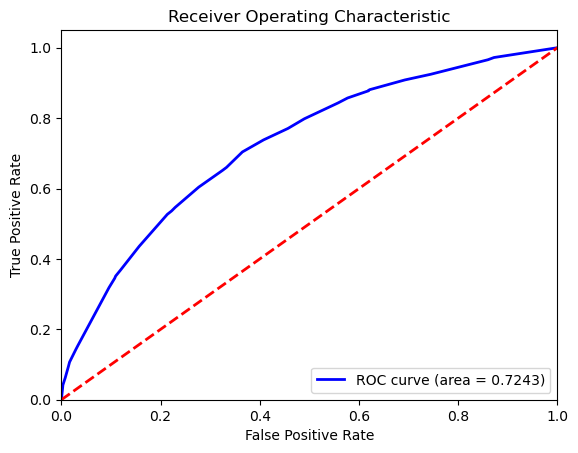

In [932]:
#  decision tree classifier for train 
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc.fit(X_train, y_train)

print(classification_report(y_test, y_pred))
cmap(dtc, X_test, y_test)
roc_curve(dtc, X_test, y_test)


              precision    recall  f1-score   support

           0       0.73      0.82      0.77      4617
           1       0.65      0.53      0.59      2983

    accuracy                           0.70      7600
   macro avg       0.69      0.67      0.68      7600
weighted avg       0.70      0.70      0.70      7600



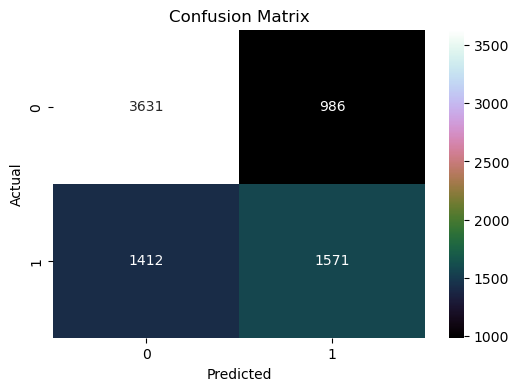

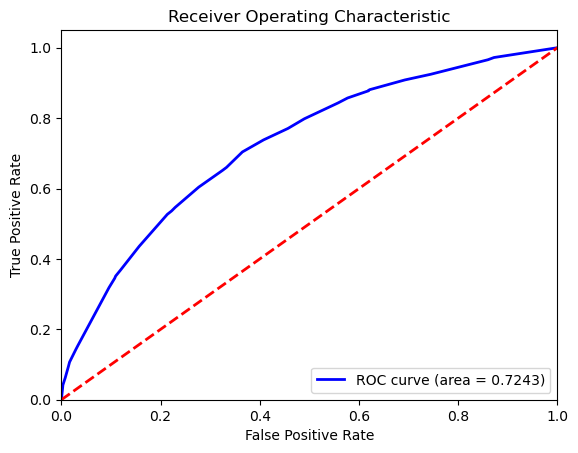

In [933]:
# random forest classifier
rfc = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rfc.fit(X_train, y_train)
print(classification_report(y_test, y_pred))
cmap(dtc, X_test, y_test)
roc_curve(dtc, X_test, y_test)



              precision    recall  f1-score   support

           0       0.73      0.82      0.77      4617
           1       0.65      0.53      0.59      2983

    accuracy                           0.70      7600
   macro avg       0.69      0.67      0.68      7600
weighted avg       0.70      0.70      0.70      7600



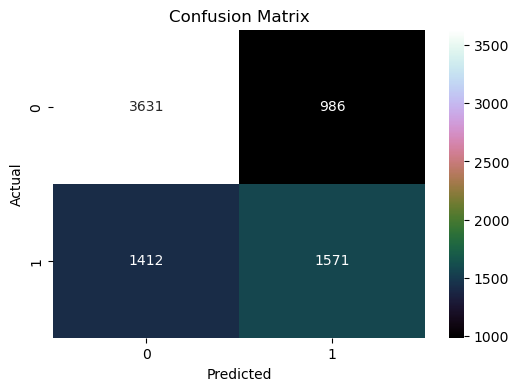

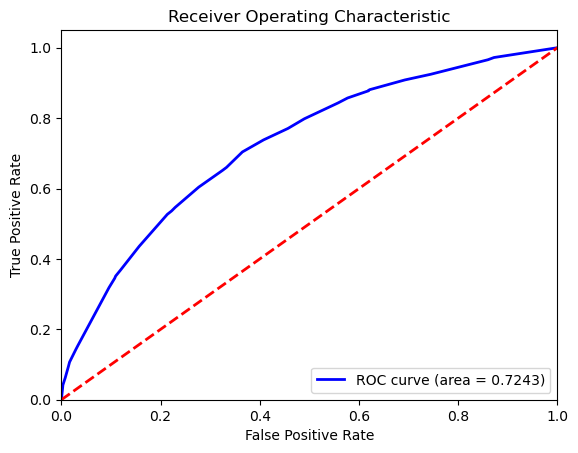

In [934]:
xgbc = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
xgbc.fit(X_train, y_train)
print(classification_report(y_test, y_pred))
cmap(dtc, X_test, y_test)
roc_curve(dtc, X_test, y_test)




In [935]:
# compare all model
print("Baseline Model:")
print(classification_report(y_test, y_pred))
print("Decision Tree Classifier:")
print(classification_report(y_test, dtc.predict(X_test)))
print("Random Forest Classifier:")
print(classification_report(y_test, rfc.predict(X_test)))
print("XGBoost Classifier:")
print(classification_report(y_test, xgbc.predict(X_test)))


Baseline Model:
              precision    recall  f1-score   support

           0       0.73      0.82      0.77      4617
           1       0.65      0.53      0.59      2983

    accuracy                           0.70      7600
   macro avg       0.69      0.67      0.68      7600
weighted avg       0.70      0.70      0.70      7600

Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      4617
           1       0.61      0.53      0.57      2983

    accuracy                           0.68      7600
   macro avg       0.67      0.66      0.66      7600
weighted avg       0.68      0.68      0.68      7600

Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.69      0.88      0.78      4617
           1       0.68      0.39      0.50      2983

    accuracy                           0.69      7600
   macro avg       0.69      0.64      0.64      7600
weight

In [ ]:
# hyoer parameter tuning for xgboost
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [1, 3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)


In [ ]:
# best model 

best_xgbc = XGBClassifier(
    **grid_search.best_params_,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

best_xgbc.fit(X_train, y_train)

print(classification_report(y_test, best_xgbc.predict(X_test)))
cmap(best_xgbc, X_test, y_test)
roc_curve(best_xgbc, X_test, y_test)




In [938]:
# cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
from sklearn.metrics import roc_auc_score


# lgbm = LGBMClassifier(
#     objective="binary",
#     is_unbalance=True,
#     random_state=42
# )


# param_dist = {
#     "n_estimators": [250, 500, 800],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "num_leaves": [31, 64, 128],
#     "max_depth": [-1, 3, 5],
#     "min_child_samples": [20, 50, 100],
#     "subsample": [0.7, 0.8, 1.0],
#     "colsample_bytree": [0.7, 0.8, 1.0],
#     "reg_alpha": [0, 0.1, 1],
#     "reg_lambda": [0, 0.1, 1, 5]


# }

# search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=param_dist,
#     n_iter=40,              # increase to 80+ if time allows 🚀
#     scoring="roc_auc",
#     cv=cv,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# search.fit(X_train, y_train)

# print("Best Params:", search.best_params_)
# print("Best CV AUC:", search.best_score_)

# best_model = search.best_estimator_

# y_prob = best_model.predict_proba(X_test)[:, 1]
# auc = roc_auc_score(y_test, y_prob)
# roc_curve(best_model, X_test, y_test)
# print("FINAL TEST AUC:", auc)


In [939]:
# prob_lgbm = search.predict_proba(X_test)[:, 1]
# prob_xgb = xgbc.predict_proba(X_test)[:, 1]

# w1, w2 = 0.6, 0.4   

# ensemble_prob = (w1 * prob_lgbm) + (w2 * prob_xgb)

# auc = roc_auc_score(y_test, ensemble_prob)
# print("ENSEMBLE AUC:", round(auc, 5))

# thresholds = np.arange(0.2, 0.8, 0.05)
# f1_scores = []

# for t in thresholds:
#     y_pred_temp = (ensemble_prob > t).astype(int)
#     f1_scores.append(f1_score(y_test, y_pred_temp))

# best_threshold = thresholds[np.argmax(f1_scores)]
# print("Best Threshold:", best_threshold)

# # Final prediction
# y_pred = (ensemble_prob > best_threshold).astype(int)

# print("\n=== Classification Report ===")
# print(classification_report(y_test, y_pred))


In [940]:
logreg = LogisticRegression(
    C=0.5,              # regularization strength
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train, y_train)

y_prob = logreg.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("Logistic Regression AUC:", round(auc, 5))


Logistic Regression AUC: 0.75335


In [941]:

param_grid = [
    {
        "C": [0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.5],
        "penalty": ["l2"],
        "solver": ["lbfgs", "newton-cg", "sag"]
    },
    {
        "C": [0.05, 0.1, 0.3, 0.5, 1.0],
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"]
    },
    {
        "C": [0.05, 0.1, 0.3, 0.5, 1.0],
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "l1_ratio": [0.2, 0.4, 0.6, 0.8]
    }
]

grid = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=3000),
    param_grid,
    scoring="roc_auc",
    cv=7,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)


grid.fit(X_train, y_train)

print("Best:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)


Fitting 7 folds for each of 51 candidates, totalling 357 fits
Fitting 7 folds for each of 51 candidates, totalling 357 fits
Best: {'C': 0.5, 'penalty': 'l2', 'solver': 'sag'}
Best CV AUC: 0.7572428855711993


In [942]:

best_model = grid.best_estimator_

# Evaluate
y_prob = best_model.predict_proba(X_scaled)[:, 1]
auc = roc_auc_score(y, y_prob)

print("Test AUC:", round(auc, 5))


Test AUC: 0.75708


In [943]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "weight": best_model.coef_[0]
}).sort_values(by="weight", ascending=False)

print(coef_df)



              feature    weight
15  loan_income_ratio  0.541440
6               num_7  0.484107
9               cat_2  0.140046
5               num_6  0.101695
7               num_9  0.075633
16    monthly_payment  0.037176
0                  id -0.002479
10              cat_3 -0.016573
2               num_3 -0.024225
13              cat_6 -0.049881
8               cat_1 -0.083576
11              cat_4 -0.084224
3               num_4 -0.110882
12              cat_5 -0.135638
14              cat_7 -0.150034
4               num_5 -0.350747
1               num_1 -0.607964


In [944]:
test = pd.read_csv("secret_test_features.csv")

cat_cols = test.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    test[col] = LabelEncoder().fit_transform(test[col].astype(str))
    
test["loan_income_ratio"] = test["num_3"] / (test["num_2"] + eps)
test["monthly_payment"] = test["num_3"] / (test["num_8"] + eps)

drop_cols = [
    "num_2",
    "num_8"
]

test = test.drop(columns=drop_cols)



best_model = grid.best_estimator_

X_scaled = scaler.transform(test)

# Evaluate
y_pred = best_model.predict(X_scaled)
y_prob = best_model.predict_proba(X_scaled)[:, 1]
submission = pd.DataFrame({
    "id": test["id"],
    "prediction": y_pred,
    "probability": y_prob
})

print(submission.head())

   id  prediction  probability
0   0           0     0.397558
1   1           1     0.612945
2   2           0     0.360768
3   3           1     0.500007
4   4           0     0.342111


In [945]:
submission.to_csv("gachajogja.csv", index=False)